<a href="https://colab.research.google.com/github/IHMilon/MiniHybrid-Vision-Transformer/blob/main/Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **New Hybrid model on EuroSAT**
  
This project highlights how I implemented and designed a **New efficient Hybrid Model**, all while working with limited computing resources.

##  **Dataset Gathering**
The **EuroSAT** dataset was obtained from [Kaggle](https://www.kaggle.com/datasets/apollo2506/eurosat-dataset), a widely recognized platform for open-access datasets.

In [1]:
# Create .kaggle dir for API key file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
# Download the zip data file
!kaggle datasets download -d apollo2506/eurosat-dataset 1>/dev/null

In [3]:
# Unzip the dataset
!unzip /content/eurosat-dataset.zip -d datasets/ 1>/dev/null

## **Install Required Packages**

In [ ]:
!pip install torchprofile
!pip install split-folders

## **Import Required Libraries**

In [34]:
import os
import time
import random
import warnings
import math
import numpy as np
import splitfolders
from PIL import Image
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torchprofile import profile_macs
from sklearn.metrics import confusion_matrix

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

## **Reproducibility**

In [6]:
torch.manual_seed(29)
random.seed(29)
np.random.seed(29)
torch.cuda.manual_seed(29)

## **Set the Device**

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device is: {device}")

Device is: cuda


## Inspecting and Cleaning the Dataset

Before training, it's important to make sure the dataset is complete and free from any broken or missing samples.  
This step ensures the model learns from clean, high-quality data during both training and testing.

In [8]:
# Dataset path
data_path = "/content/datasets/EuroSAT"

In [9]:
# Check num_samples and remove corrupt images.
def inspect(data_dir):
    removed_files = 0
    total_img = 0
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            path = os.path.join(root, file)
            if file.endswith(('.csv','.json')):
                os.remove(path)
                continue
            else:
                try:
                    img = Image.open(path)
                    total_img += 1
                    img.verify()
                except Exception as e:
                    os.remove(path)
                    removed_files += 1
    return total_img, removed_files

total_img, removed_img = inspect(data_path)
print(f"Total samples: {total_img}\nRemoved samples: {removed_img}")

Total samples: 27000
Removed samples: 0


In [10]:
# Inspect all samples shape
shapes = []
for root, dir, files in os.walk(data_path):
    for file in files:
        if file.lower().endswith(('.jpg','.jpeg','.png')):
            path = os.path.join(root, file)
            image = Image.open(path)
            shapes.append((image.size[1], image.size[0], len(image.getbands())))
unique_shapes = set(shapes)
print(f"All image shapes: {unique_shapes}")

All image shapes: {(64, 64, 3)}


In [11]:
# Samples per class
print("Samples per Class....\n")
for i, folder in enumerate (os.listdir(data_path)):
    folder_path = os.path.join(data_path, folder)
    print(f"{i+1}. {folder}: {len(os.listdir(folder_path))}")

Samples per Class....

1. Residential: 3000
2. HerbaceousVegetation: 3000
3. AnnualCrop: 3000
4. Highway: 2500
5. Industrial: 2500
6. PermanentCrop: 2500
7. SeaLake: 3000
8. Pasture: 2000
9. Forest: 3000
10. River: 2500


## **Split the Dataset**
The dataset was split into 80% training and 20% validation sets.

In [ ]:
input_folder = "/content/datasets/EuroSAT"
output_folder = "/content/splited"
split_ratio = (0.8, 0.2)
seed = 29

# Split the folder to train and val set
splitfolders.ratio(
      input = input_folder,
      output = output_folder,
      ratio = split_ratio,
      seed = seed
      )

###Samples per Class After Splitting

Here’s how the dataset is distributed across all classes after the train-test split.

In [13]:

output_folder = "/content/splited"
split_folder = ["train","val"]
print("Class distribution after splitting:")
for folder in split_folder:
    print(f"\n------{folder} folder-------")
    path = os.path.join(output_folder,folder)
    for dir in os.listdir(path):
        class_path = os.path.join(path,dir)
        files = len(os.listdir(class_path))
        print(f"{dir}: {files}")

Class distribution after splitting:

------train folder-------
Residential: 2400
HerbaceousVegetation: 2400
AnnualCrop: 2400
Highway: 2000
Industrial: 2000
PermanentCrop: 2000
SeaLake: 2400
Pasture: 1600
Forest: 2400
River: 2000

------val folder-------
Residential: 600
HerbaceousVegetation: 600
AnnualCrop: 600
Highway: 500
Industrial: 500
PermanentCrop: 500
SeaLake: 600
Pasture: 400
Forest: 600
River: 500


##  Custom Dataset Class

I created a custom dataset class by extending PyTorch’s `Dataset` class to efficiently load images and apply the necessary transformations on the fly.

In [14]:
# Custom Dataset Class
class EuroSAT(Dataset):
    def __init__(self, root, transforms = None):
        self.transforms = transforms
        self.img_paths = []
        self.labels = []

        # Convert class name to label index
        self.classes = sorted(os.listdir(root))
        self.class2idx = {cls: idx for idx, cls in enumerate(self.classes)}

        # Store all the image paths and labels to the defined list
        for folder in os.listdir(root):
           folder_path = os.path.join(root,folder)
           for file in os.listdir(folder_path):
               file_path = os.path.join(folder_path,file)
               self.img_paths.append(file_path)
               self.labels.append(self.class2idx[folder])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Collect image at the index
        image = self.img_paths[idx]
        image = Image.open(image).convert("RGB") # Ensure image is in RGB format
        label = self.labels[idx]

        if self.transforms:
            # Apply transforms to image
            image = self.transforms(image)

        return image, label

##  Data Augmentation

I applied several data augmentation techniques to expand the dataset and help the model learn more general patterns, improving its overall performance.

In [15]:
train_transforms = transforms.Compose([
     transforms.RandomCrop(64, padding = 5),
     transforms.RandomHorizontalFlip(),
     transforms.RandomRotation(10),
     transforms.ColorJitter(brightness = 0.3,
                contrast = 0.2,
                saturation = 0.3,
                hue = 0.2),
     transforms.ToTensor()
     ])

# Test set is only converted to Tensor
test_transforms = transforms.ToTensor()

##  Batch Preparation

To ensure each batch contains a balanced mix of classes and loads efficiently, I created a custom DataLoader for the dataset.

In [16]:
train_path = "/content/splited/train"
train_dataset = EuroSAT(train_path, transforms = train_transforms)
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True, pin_memory = True)

val_path = "/content/splited/val"
val_dataset = EuroSAT(val_path, transforms = test_transforms)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle = False, pin_memory = True)

##  Visualization of Batch Images

Here, I visualized a few sample batches to check that the transformations were applied correctly and the images were loading as expected.

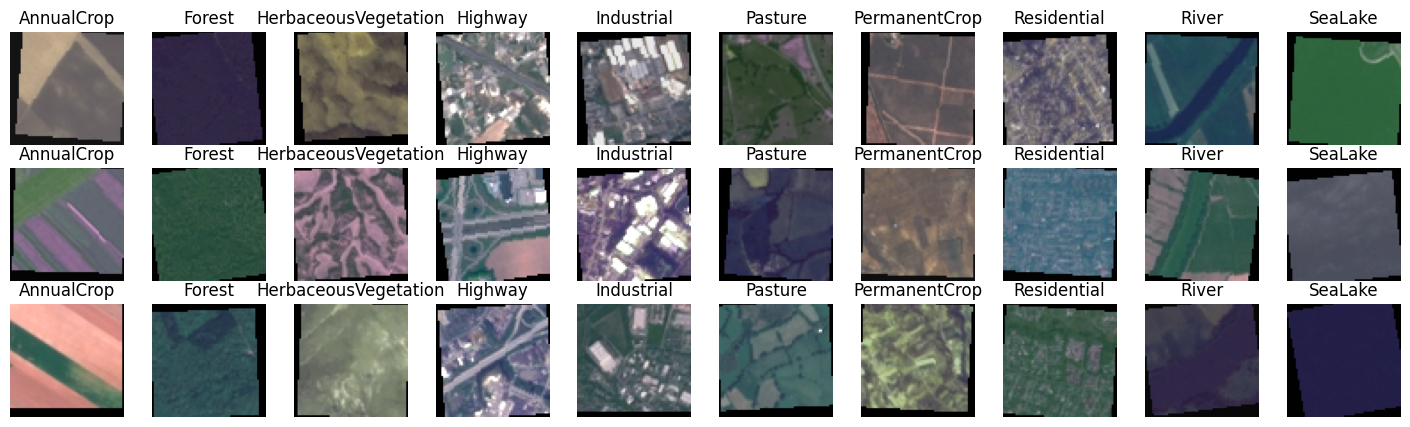

In [17]:
# Collect 3 samples from each class for visu.
samples = [[] for _ in range(10)]
for image, label in train_dataset:
    if len(samples[label]) < 3:
        samples[label].append(image)

# Visualize the collected images
plt.figure(figsize = (18, 5))
for idx in range(30):
    label = idx % 10
    image = samples[label][idx//10]

    # Covert shape CHW to HWC for Vis.
    image = image.permute(1,2,0)
    # Convert label idx to name
    label = train_dataset.classes[label]

    # Create subplot for vis.
    plt.subplot(3, 10, 1+idx)
    plt.imshow(image)
    plt.title(label)
    plt.axis("off")
plt.show()

##  Batch Size Inspection

I checked the batch shapes to make sure the data was loaded correctly and organized properly before feeding it into the model.

In [18]:
for images, labels in train_loader:
    print(f"Images Shapes: {images.shape}")
    print(f"Labels shapes: {labels.shape}")
    break

Images Shapes: torch.Size([64, 3, 64, 64])
Labels shapes: torch.Size([64])


# **Model Architecture**
This model is designed for high efficiency image classification (trained on the **EuroSAT** dataset), focusing on minimizing parameters while maintaining high accuracy for edge deployment.

## 1. Feature Extraction (CNN Backbone)
* **Inverted Residual Blocks (MBConv):** The model starts with MBBlocks to extract local spatial features.
* **Dimensionality Reduction:** It projects the input into **150 channels** and reduces the spatial dimensions to a bottleneck of **8×8**.

## 2. Custom Latent Attention Block
Instead of using standard linear projections for MHA, this model uses a unique **Channel-Splitting Strategy**:
* **Q, K, V Generation:** The 150 channel feature map is split into three parallel groups of **50 channels** each.
* **Sequence Transformation:** Each group is flattened into a 64 length sequence to represent Queries ($Q$), Keys ($K$), and Values ($V$).
* **Attention Mechanism:** Standard self attention is applied to capture global dependencies across these channels.

### 3. Iterative Refinement & Expansion
* **Projection:** After the attention mechanism, the 50 channel output is projected back to 150 channels with `conv1d`.
* **Repeatability:** This custom block is used multiple times to refine the feature representation iteratively

In [19]:
# MBConv Block
class MBConv(nn.Module):
    def __init__(self, in_channel, out_channel, stride):
        super().__init__()
        self.stride = stride
        # Expansion
        self.conv1 = nn.Conv2d(in_channel, 3 * in_channel, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(3 * in_channel)
        # Depthwise Convolution
        self.conv2 = nn.Conv2d(
            3 * in_channel, 3 * in_channel, kernel_size=3, stride=stride, padding=1, groups= 3* in_channel, bias=False
        )
        self.bn2 = nn.BatchNorm2d(3 * in_channel)
        # Linear projection
        self.conv3 = nn.Conv2d(3 * in_channel, out_channel, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channel)

        self.relu6 = nn.ReLU6(inplace=True)

    def forward(self, x):
        skip = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu6(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu6(x)

        x = self.conv3(x)
        x = self.bn3(x)

        if self.stride == 1 and skip.shape == x.shape:
            x = x + skip

        return x

In [20]:
# SelfAttention Block
class SelfAttention(nn.Module):
    def __init__(self, key_dim = 64):
        super().__init__()
        self.key = key_dim
        self.transform = nn.Linear(64, self.key)
        self.expand = nn.Conv1d(50, 150, kernel_size = 1)

    def forward(self, x):
        q = x[ : ,0:50]
        k = x[ : ,50:100]
        v = x[ : ,100:150]

        Q = self.transform(q)
        K = self.transform(k)
        V = self.transform(v)

        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1))  # (B, E, E)
        scores = scores / math.sqrt(self.key) # scale for softmax
        attn = F.softmax(scores, dim = -1)
        out = torch.matmul(attn, V)  # (B, E, head_dim)

        # Expand the channels
        out = self.expand(out)
        return out


class MHA(nn.Module):
    def __init__(self, num_heads):
        super().__init__()
        self.heads = num_heads
        assert 64 % num_heads == 0
        self.key_dim = 64 // num_heads
        self.mha = nn.ModuleList([
            SelfAttention(self.key_dim)
            for _ in range(num_heads)
        ])
        self.proj = nn.Linear(64, 64)

    def forward(self, x):
        out = [attention(x) for attention in self.mha]
        out = torch.cat(out, 2)
        out = self.proj(out)
        return out


class MLP(nn.Module):
    def __init__(self, hidden_dim, dropout = 0.1):
        super().__init__()
        self.mlp = nn.Sequential(
             nn.Linear(64, hidden_dim),
             nn.GELU(),
             nn.Dropout(dropout),
             nn.Linear(hidden_dim, 64),
             nn.Dropout(dropout)
             )

    def forward(self, x):
        out = self.mlp(x)
        return out

class Encoder(nn.Module):
    def __init__(self,num_heads = 8, hidden_dim = 1024, dropout = 0.1):
        super().__init__()
        self.mha = MHA(num_heads)
        self.mlp = MLP(hidden_dim, dropout)
        self.layernorm1 = nn.LayerNorm(64)
        self.layernorm2 = nn.LayerNorm(64)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        skip = x
        out = self.layernorm1(x)
        out = self.mha(out)
        out = self.dropout(out)
        out1 = out + skip
        out = self.layernorm2(out1)
        out = self.mlp(out)
        out = self.dropout(out)
        out = out1 + out
        return out

class PredHead(nn.Module):
    def __init__(self, num_classes, dropout = 0.1):
        super().__init__()
        self.predhead = nn.Sequential(
             nn.LayerNorm(64),
             nn.Linear(64, num_classes),
             )
    def forward(self, x):
        out = self.predhead(x)
        return out

In [21]:
# Vision Transformer Model
class ViT(nn.Module):
    def __init__(self, hidden_dim = 1024, num_heads = 8, num_layers = 12, num_classes = 10, dropout = 0.1):
        super().__init__()

        self.layer1 = MBConv(in_channel = 3, out_channel = 32, stride=1)
        self.layer2 = MBConv(in_channel = 32, out_channel = 32, stride=2)
        self.layer3 = MBConv(in_channel = 32, out_channel = 64, stride=1)
        self.layer4 = MBConv(in_channel = 64, out_channel = 64, stride=2)
        self.layer5 = MBConv(in_channel = 64, out_channel = 90, stride=1)
        self.layer6 = MBConv(in_channel = 90, out_channel = 150, stride=2)

        # Positional information
        self.pos = nn.Parameter(torch.rand(1, 150, 64))

        # Instantiate the Encoder Block
        encoder_dim = [Encoder(num_heads, hidden_dim, dropout) for _ in range(num_layers)]
        self.encoder = nn.Sequential(*encoder_dim)
        # Prediction Head
        self.pred = PredHead(num_classes, dropout)

    def forward(self, x):

        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out) # (B, C, 16, 16)
        out = self.layer5(out)
        out = self.layer6(out)
        out = out.view(out.size(0), out.size(1), 8*8) # (B, C, 256)

        # Add the positional information
        patch_emb = out + self.pos

        # Pass it to the encoder layers
        out = self.encoder(patch_emb)

        # Extract the class token
        cls_token = out.mean(dim = 1)

        # Pass to the prediction head for classification
        pred = self.pred(cls_token)
        return pred

### **Instantiate the Model and Move to GPU**

In [22]:
model = ViT(hidden_dim = 256, num_heads = 8, num_layers = 5, num_classes = 10, dropout = 0.0)
model = model.to(device)

## **Model Size**

The total number of trainable parameters gives an idea of the model’s size and complexity.

In [23]:
num_params = 0
for params in model.parameters():
    if params.requires_grad:
        num_params += params.numel()
print(f"Total Parameters: {(num_params/10**6):.2f} Million")

Total Parameters: 0.67 Million


The Model has only 0.7M parameters

## **Computation Cost**

The computational cost of a model shows how much work is required to make a prediction.  
A common way to measure this is using **Multiply–Accumulate Operations (MACs)**, which counts the total computations performed during inference.

In [24]:
warnings.filterwarnings("ignore")

x = torch.ones(1, 3, 64, 64).to(device)
macs = profile_macs(model, x)
print(f"Total MACs: {(macs/1000000):.2f} Million")

Total MACs: 98.00 Million


It has total 98M MACs which is quite a few compared to others.

## **Training Setup**

The model is trained using **CrossEntropyLoss** as the objective function and the **AdamW optimizer** with weight decay for regularization.

In [25]:
Epochs = 50
# Loss function
criterion = nn.CrossEntropyLoss()
# Optimization Algorithm
optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 0.0001)

## **Training Function (One Epoch)**

This function handles the training of the model for a single epoch, including forward pass, loss computation, and backpropagation.

In [26]:
def train(model, train_loader, criterion, optimizer, device):

    # Set to training mode
    model.train()
    epoch_loss = 0
    num_samples = 0
    num_correct = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()  # compute gradients

        optimizer.step()

        # Convert logits to class index
        preds = outputs.argmax(dim = 1)

        # update the training matrices
        epoch_loss += loss.item()
        num_samples += labels.size(0)
        num_correct += (preds == labels).sum().item()

    return epoch_loss/len(train_loader), (num_correct/num_samples)*100

## **Evaluation Function (One Epoch)**

This function evaluates the model on the validation set for a single epoch, computing the loss and accuracy to track performance.

In [27]:
def evaluate(model, test_loader, criterion, device):

    # Set to evaluation mode
    model.eval()
    epoch_loss = 0
    num_samples = 0
    num_correct = 0
    with torch.inference_mode():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Convert to class index
            preds = outputs.argmax(dim = 1)

            # update test matrices
            epoch_loss += loss.item()
            num_samples += labels.size(0)
            num_correct += (preds == labels).sum().item()

    return epoch_loss/len(test_loader), (num_correct/num_samples)*100

## **Training Loop**

The model is trained over multiple epochs, updating weights with the optimizer and tracking **loss** and **accuracy** on both training and validation sets to monitor learning progress.

In [28]:
# Store the acc & loss for each epoch
train_losses, train_accs = [], []
test_losses, test_accs =[], []

# Start time
start_time = time.time()

# Train the model
for i in range(1, Epochs+1):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss/len(train_loader))
    train_accs.append(train_acc)

    test_losses.append(test_loss/len(val_loader))
    test_accs.append(test_acc)

    if i % 10 == 0:
        print(f"{i}.Train Accuracy {train_acc:.2f}%, Test Accuracy {test_acc:.2f}%")
        print("-"*50)

# Calculate the Training Time
end_time = time.time()
total_time = end_time - start_time
print(f"\nTotal time to train the model is {(total_time/60):.2f} Minutes")

10.Train Accuracy 77.90%, Test Accuracy 82.78%
--------------------------------------------------
20.Train Accuracy 86.87%, Test Accuracy 89.67%
--------------------------------------------------
30.Train Accuracy 90.28%, Test Accuracy 92.44%
--------------------------------------------------
40.Train Accuracy 91.95%, Test Accuracy 93.30%
--------------------------------------------------
50.Train Accuracy 93.02%, Test Accuracy 94.31%
--------------------------------------------------

Total time to train the model is 54.31 Minutes


## **Loss & Accuracy Plot**

Visualizing the training and validation **loss** and **accuracy** helps understand the model’s learning behavior and identify any signs of overfitting.

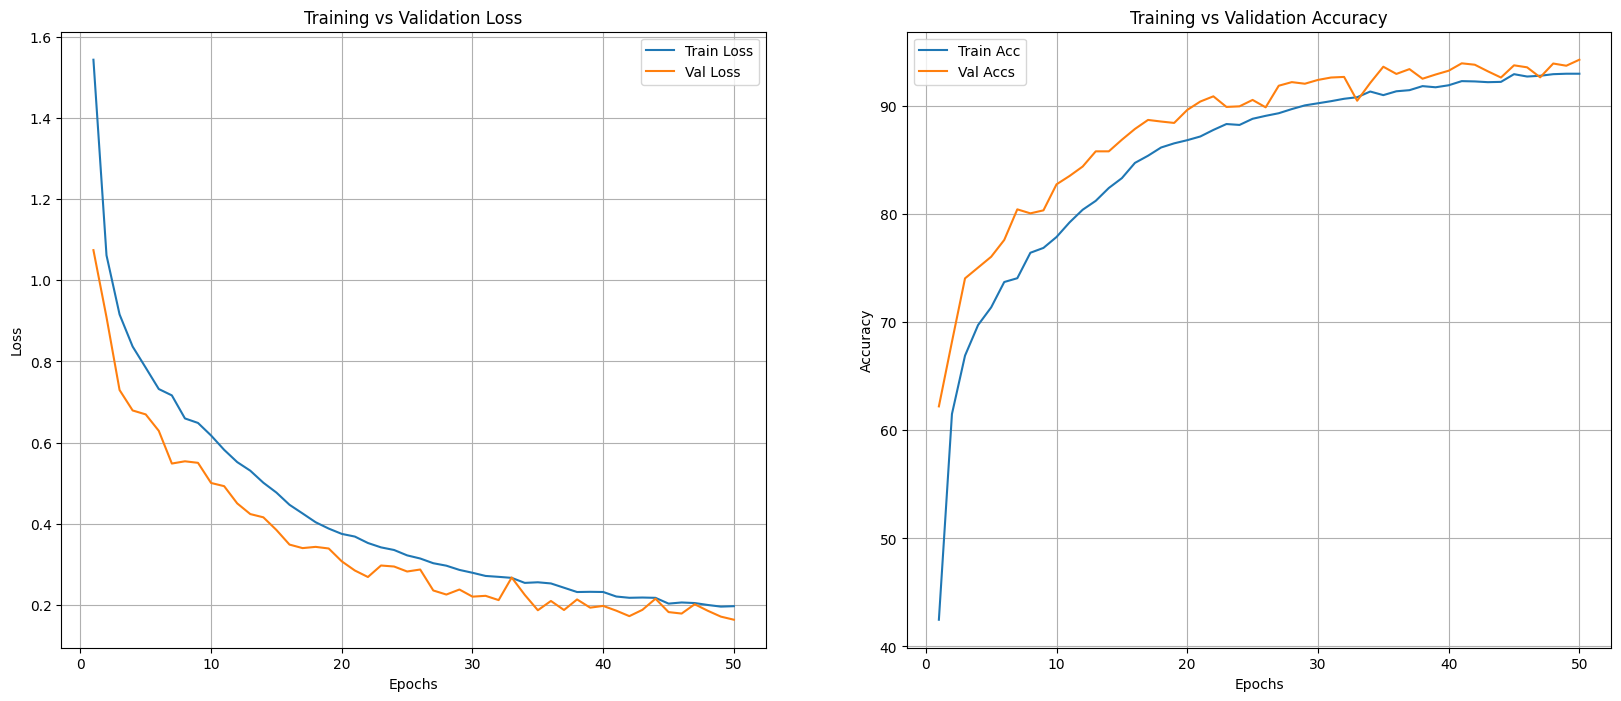

In [31]:
epoch_range = range(1,Epochs+1)
plt.figure(figsize=(20,8))

t_losses = []
for i in train_losses:
    loss = i * len(train_loader)
    t_losses.append(loss)
te_losses = []
for i in test_losses:
    loss = i * len(val_loader) # Changed from test_loader to val_loader
    te_losses.append(loss)

# Plot the Train and Val loss
plt.subplot(1,2,1)
plt.plot(epoch_range, t_losses, label = "Train Loss")
plt.plot(epoch_range, te_losses, label = "Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# Plot the Train and Val Accuracy
plt.subplot(1,2,2)
plt.plot(epoch_range, train_accs, label = "Train Acc")
plt.plot(epoch_range, test_accs, label = "Val Accs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## **Prediction Visualization**

I visualized the model’s predictions on the test set to see how well it performs across different classes.

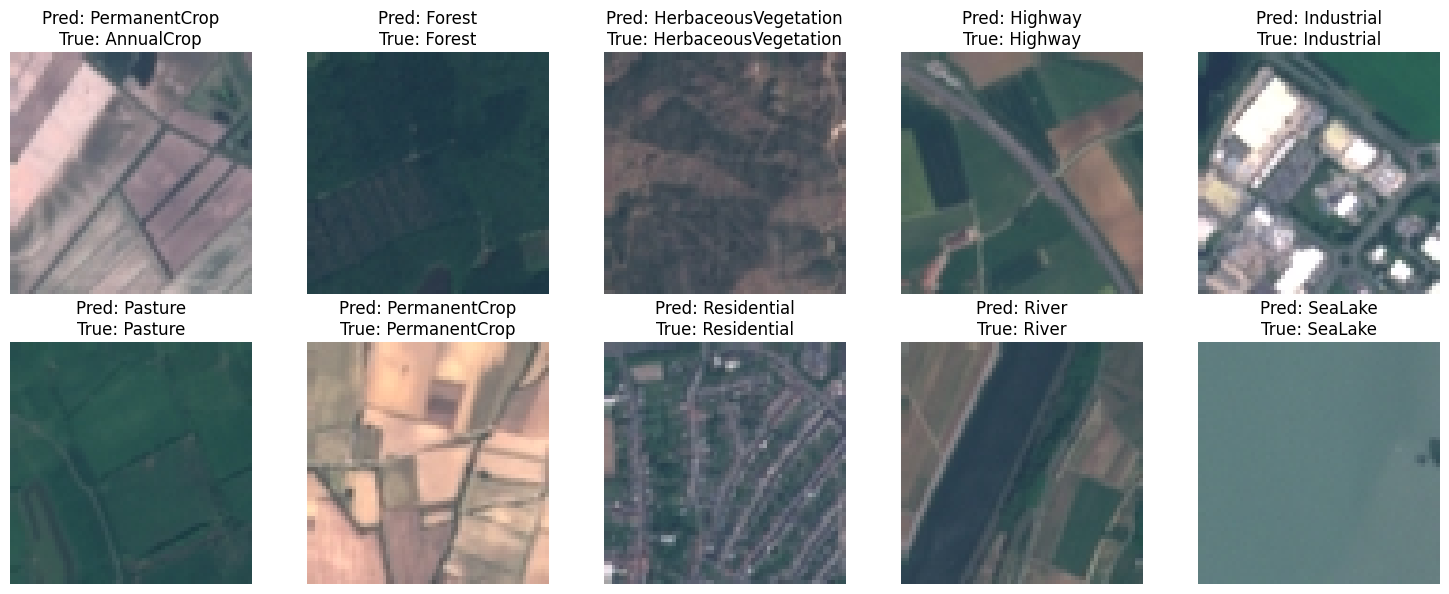

In [47]:
num_classes = len(val_dataset.classes)
#Get single sample from each class
samples = [ [] for _ in range(num_classes)]
for image, label in val_dataset:
    if len(samples[label]) < 4:
        samples[label].append(image)

plt.figure(figsize=(15, 6))
for idx in range(num_classes):
    # Ensure a sample exists for this idx before trying to access it
    if not samples[idx]:
        continue

    image = samples[idx][0]
    label = idx

    # Forward pass
    model.eval()
    with torch.inference_mode():
        output = model(image.unsqueeze(dim=0).to(device))

    # Convert to label index
    pred = output.argmax(dim=1)

    # Get class name
    true_name = val_dataset.classes[label]
    pred_name = val_dataset.classes[pred.item()]

    # convert CHW to HWC for visualization
    image = image.permute(1,2,0)

    plt.subplot(2, 5, idx + 1)
    plt.imshow(image)
    plt.title(f"Pred: {pred_name}\nTrue: {true_name}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## **Confusion Matrix**

The confusion matrix shows how well the model predicts each class on the test set and highlights which classes are most often misclassified.

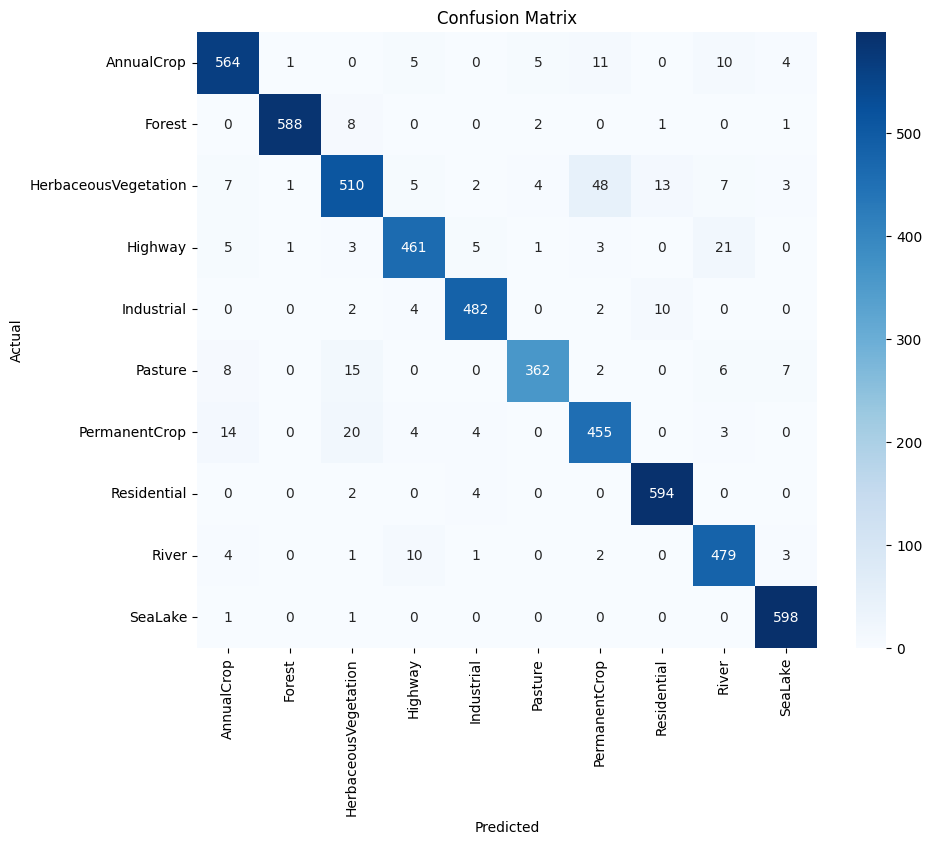

In [35]:
# Collect predictions and true labels
true_labels = []
predictions = []

model.eval()
with torch.inference_mode():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        pred = outputs.argmax(dim=1)
        true_labels.extend(labels.cpu().numpy())
        predictions.extend(pred.cpu().numpy())

# Compute confusion matrix
matrix = confusion_matrix(true_labels, predictions)

# Get class name from label index
class_name = val_dataset.classes

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True, fmt='d', xticklabels=class_name, yticklabels=class_name, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## **Latency and Throughput**

We evaluate the model’s performance by measuring **inference time (latency)** and **samples processed per second (throughput)**, giving insights into its efficiency in real-world scenarios.

In [36]:
# Measure latency
starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
repetitions = 300
timings = np.zeros((repetitions, 1))
model.eval()

with torch.inference_mode():
    for rep in range(repetitions):
        starter.record()
        _ = model(images) # Use the last batch of images from the validation loader
        ender.record()
        # Wait for GPU to synchronize
        torch.cuda.synchronize()
        curr_time = starter.elapsed_time(ender)
        timings[rep] = curr_time

mean_latency = np.sum(timings) / repetitions
print(f"Mean Latency: {mean_latency:.2f} ms")

# Measure throughput
batch_size = images.shape[0]
throughput = batch_size / (mean_latency / 1000)
print(f"Throughput: {throughput:.2f} samples/sec")

Mean Latency: 17.16 ms
Throughput: 1398.78 samples/sec
